<a href="https://colab.research.google.com/github/goniwet92/Data-Analyst-/blob/main/Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Thembelani Goniwe

1. OVERVIEW

Retail sales data analysis containing 1000 entries from Jan 2023 to Jan 2024, covering 3 product categories (Beauty, Clothing and Electronics).

2. OBJECTIVE


Explore retail transactions to ;
  Uncover sales patterns
  Customer behaviour trends
  And give recommendations to management.

3. TECH STACK

Python, pandas, matplotlib.pyplot, seabon.

4. STRUCTURE OF THE NOTEBOOK
   
**Load dataset and quick inspection

**Descriptive statistics

**Time series analysis (monthly & quarterly)

**Customer demographics

**Product /category analysis

**Weekday spending pattern

**Conclusion and business recommendations

1. _LOAD THE DATA AND QUICK INSPECTION_


We load the data and check the shape of the data,column type, missing values to see how much data cleaning needs to be done before we trust the analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style =("whitegrid"))
plt.rcParams["figure.dpi"] = 100

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(("retail.csv") , parse_dates=["Date"])
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Saving retail.csv to retail.csv
Shape: 1000 rows x 9 columns


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Column data types")
print(df.dtypes)
print()

print("Missing values per column")
print(df.isnull().sum())
print()

print(f"Duplicate rows: {df.duplicated().sum()} ")
print(f"Unique customers: {df["Customer ID"].nunique()} (out of {len(df)} transactions)")

Column data types
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Missing values per column
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0 
Unique customers: 1000 (out of 1000 transactions)


_*OBSERVATION*_.

The data is clean no missing values or duplicate entries.

The are 1000 unique customer id's for 1000 transactions meaning there is no duplicate entries.

2. _DESCRIPTIVE STATISTICS_

Summary statistics for the numerical values gives us a feel of the scale and spread of the business.

In [ ]:
num_cols = ["Age", "Quantity","Price per Unit", "Total Amount"]

desc = df[num_cols].describe ().T


desc["median"] = df[num_cols].median()
desc["mode"] = df[num_cols].mode().iloc[0]
desc = desc[["mean", "median", "mode", "std", "min", "max"]]
desc.round(2)

,mean,median,mode,std,min,max
Age,41.39,42.0,43.0,13.68,18.0,64.0
Quantity,2.51,3.0,4.0,1.13,1.0,4.0
Price per Unit,179.89,50.0,50.0,189.68,25.0,500.0
Total Amount,456.00,135.0,50.0,560.00,25.0,2000.0


  _OBSERVATION_


TRANSACTIONS

The average transactions value is = R456 with a median of 135, the huge gap means there is a right skew distribution with a lot of small transactions and a few higher values (R2000) ones dragging the average up.



PRICE

The price per unit ranges from min R25 to max R500 with a standard deviation of  R190, there's a range of cheap and premium products.


QUANTITY

Quantity per transaction ranges from (1 to 4) per basket it is modest, the quantity size doesn't drive value but the price does.


AGE

The age ranges from min 18 to max 64, adult customers no minors or seniors 65+

3. _TIME SERIES ANALYSIS (Quarterly and Monthly)_

Understanding when revenue is earned help with inventory, staffing and promotional decision making.

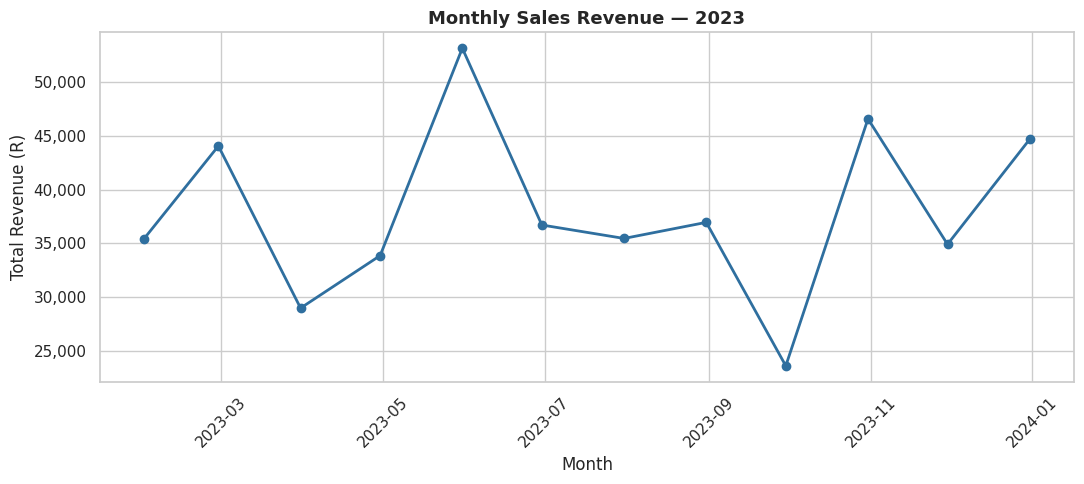

In [ ]:
ts = df.set_index("Date")

monthly = ts.resample("ME")["Total Amount"].sum()

# 2024 only has one day in January not a month so we exclude it
monthly_full = monthly[monthly.index <= "2023-12-31"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_full.index, monthly_full.values, marker="o", linewidth=2, color="#2f6f9f")
ax.set_title("Monthly Sales Revenue — 2023", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (R)")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

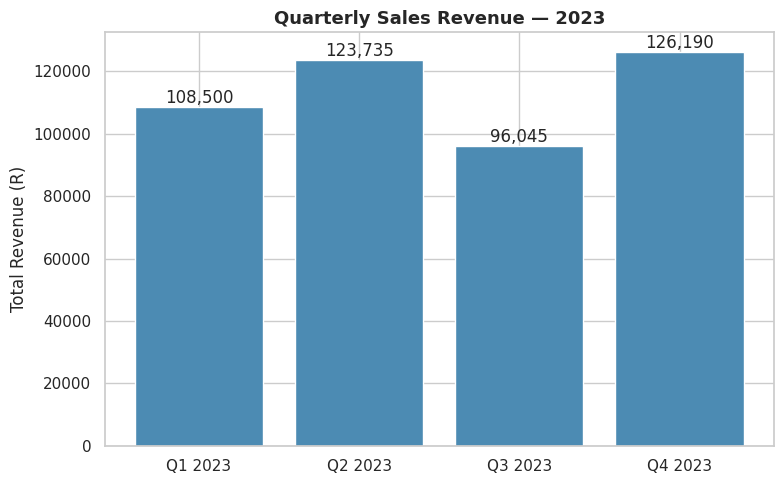

In [ ]:
quarterly = ts[ts.index <= "2023-12-31"].resample("QE")["Total Amount"].sum()

quarterly.index = [f"Q{((m-1)//3)+1} {y}" for y, m in zip(quarterly.index.year, quarterly.index.month)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly.index, quarterly.values, color="#4c8bb3")
ax.set_title("Quarterly Sales Revenue — 2023", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Revenue (R)")
ax.bar_label(bars, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

_OBSERVATION_

Monthly revenue is very volatile no trend, there is no clear recorded growth or decline.

Quarterly totals are relatively balanced there is no seasonality.

4. _CUSTOM DEMOGRAPHICS (AGE & GENDER)_

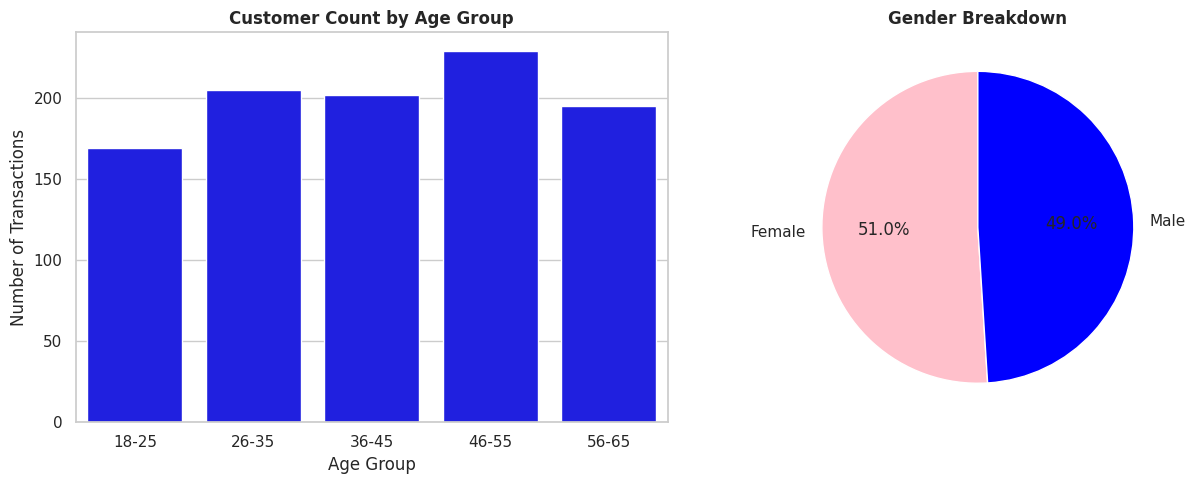

In [ ]:
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="Age Group", order=labels, ax=axes[0], color="blue")
axes[0].set_title("Customer Count by Age Group", fontweight="bold")
axes[0].set_ylabel("Number of Transactions")

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["pink", "blue"], startangle=90)
axes[1].set_title("Gender Breakdown", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Age Group", observed=True)["Total Amount"].agg(
    Transactions="count", Total_Revenue="sum", Avg_Order_Value="mean"
).round(2)

,Transactions,Total_Revenue,Avg_Order_Value
Age Group,,,
18-25,169,84550,500.30
26-35,205,98480,480.39
36-45,202,91870,454.80
46-55,229,100690,439.69
56-65,195,80410,412.36


_OBSERVATION_

Gender is almost equal no need to prioritize one gender over the other.

Customer demographic is skewed towards young people 26 - 35 to middle age 46 - 55 as they are large by transaction count.

5. _PRODUCT ANALYSIS_

 Here product are in category no specific product name only by category (Beauty, Clothing and Electronics)

In [ ]:
cat_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
cat_qty = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)
cat_aov = df.groupby("Product Category")["Total Amount"].mean().sort_values(ascending=False)

summary = pd.DataFrame({
    "Total Revenue (R)": cat_revenue,
    "Units Sold": cat_qty.reindex(cat_revenue.index),
    "Avg Order Value (R)": cat_aov.reindex(cat_revenue.index).round(2),
})
summary

,Total Revenue (R),Units Sold,Avg Order Value (R)
Product Category,,,
Electronics,156905,849,458.79
Clothing,155580,894,443.25
Beauty,143515,771,467.48


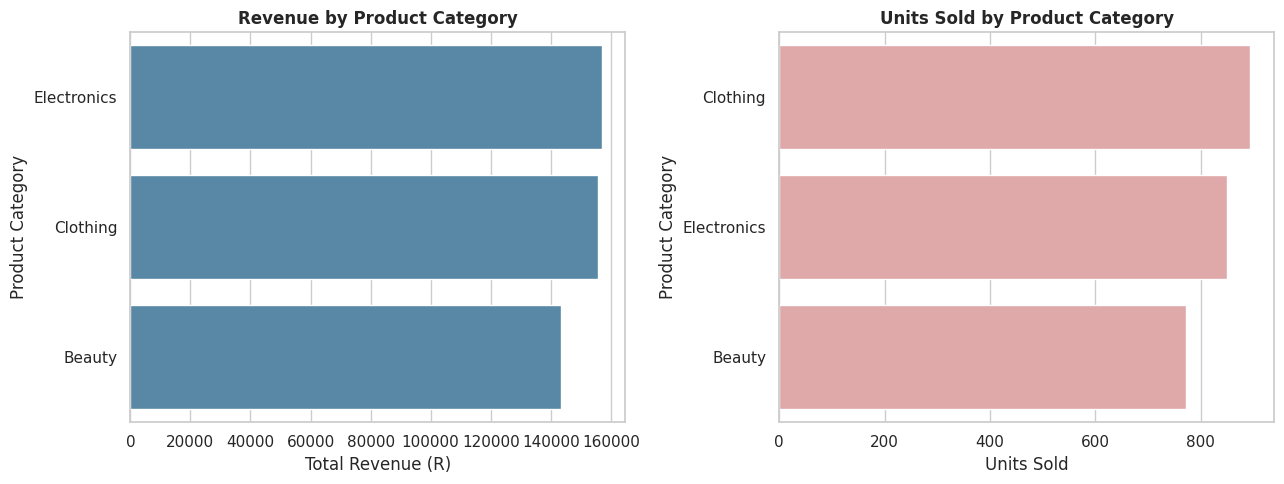

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=cat_revenue.values, y=cat_revenue.index, ax=axes[0], color="#4c8bb3")
axes[0].set_title("Revenue by Product Category", fontweight="bold")
axes[0].set_xlabel("Total Revenue (R)")

sns.barplot(x=cat_qty.values, y=cat_qty.index, ax=axes[1], color="#e8a0a0")
axes[1].set_title("Units Sold by Product Category", fontweight="bold")
axes[1].set_xlabel("Units Sold")

plt.tight_layout()
plt.show()

_OBSERVATION_

All product categories are remarkably balanced in revenue and are 9% of each other no category dominates the portfolio.

Clothing sells the most units but electronics has more revenue per unit sold because electronics has a higher average order value (R459)

Beauty has more room for growth as it has the lowest units sold and revenue.

6. _WEEKDAY SPENDING PATTERN_

To help employees with better staffing and promotional decision

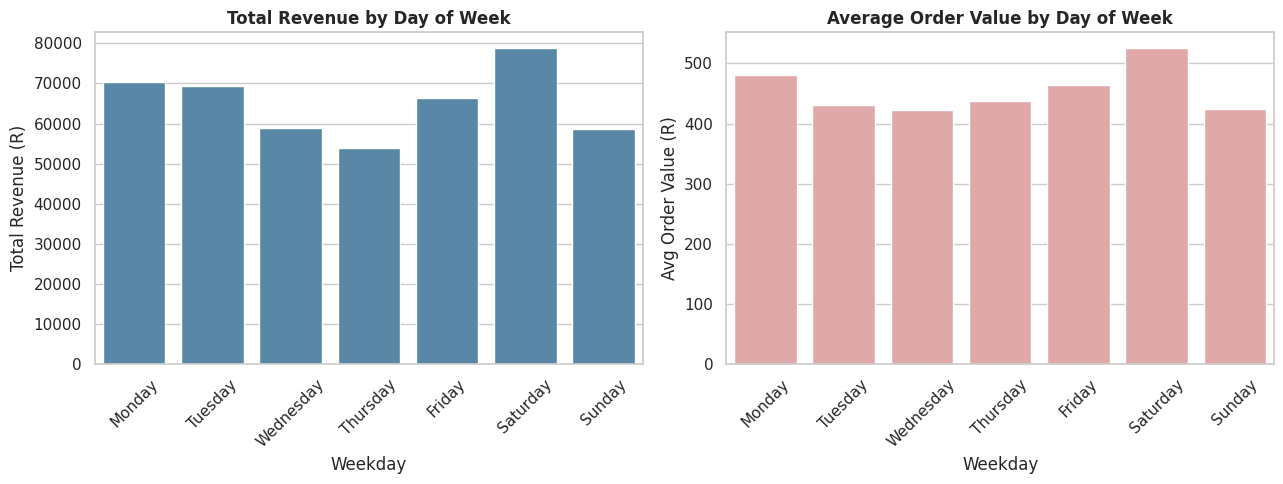

In [5]:
df["Weekday"] = df["Date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_rev = df.groupby("Weekday")["Total Amount"].sum().reindex(weekday_order)
weekday_aov = df.groupby("Weekday")["Total Amount"].mean().reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=weekday_rev.index, y=weekday_rev.values, ax=axes[0], color="#4c8bb3")
axes[0].set_title("Total Revenue by Day of Week", fontweight="bold")
axes[0].set_ylabel("Total Revenue (R)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=weekday_aov.index, y=weekday_aov.values, ax=axes[1], color="#e8a0a0")
axes[1].set_title("Average Order Value by Day of Week", fontweight="bold")
axes[1].set_ylabel("Avg Order Value (R)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

_OBSERVATION_

Saturday is the strongest revenue day consistent with the weekend shopping and Thursday being the lowest revenue day.

Weekday revenue is fairly consistent through Monday to Friday.

promotion and staffing could be directed towards the weekend Friday - Sunday.

7. _CONCLUSION AND BUSINESS RECOMMENDATIONS_

Revenue is nearly evenly split between clothing, beauty and electronics with no single category dominating.

Transaction value is driven primarily by unit price not bulk purchases.

Customers between the ages of 18-25 spend the most per transaction on average, average declines with age.

Sales show no clear seasonal growth trend rather a category mix and promotional time causes the volatility.



Actionable recommendations

Concrete marketing strategy for staffing and promotions should be done on a Friday and Saturday, scheduling promotions and ensuring inventory availability on Saturday as it generates 32% more than a Thursday.

Grow the beauty category through upsell and promotion. The beauty category has the lowest revenue and unit sales of the three categories, despite the customer base being gender-balanced.

Investigate the September revenue dip. September was the lowest-revenue month of 2023, sitting well below the surrounding months. Understanding whether this was driven by reduced footfall, a stockout, or a seasonal lull (e.g. post-winter, back-to-school competing spend) would help management decide whether a targeted September promotion is worthwhile in future years.

Tailor category products by age group since 18-25 has the highest average order value and 56-65 had the lowest.

Targeted promotion for a specific group could raise the average order value across the board.

Data limitations, there is no specific product only a category